# Deliverable 2

## Model Training and Evaluation

### Feature Selection

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

In [2]:
# Load data
df = pd.read_csv('/kaggle/input/crop-recommendation-csv/crop_recommendation.csv')  

In [3]:
# Encode target labels
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

In [4]:
# Features and target
X = df.drop(['label', 'label_encoded'], axis=1)
y = df['label_encoded']

In [5]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

RandomForestClassifier(random_state=42)

In [6]:
# Feature importances
importances = rf.feature_importances_
feature_names = X.columns

In [7]:
# Create a DataFrame for better visualization
feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

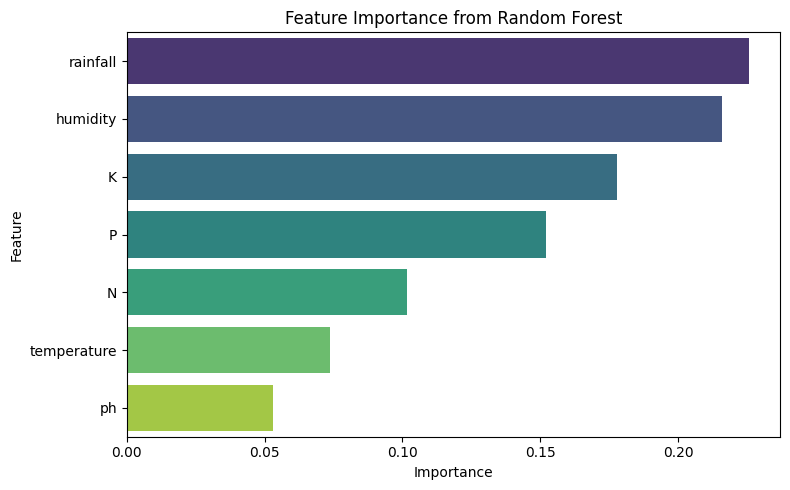

In [8]:
# Plot
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Feature Importance from Random Forest')
plt.tight_layout()
plt.show()

Although pH and temperature are the least influential, all features contribute meaningfully (>0.05), so we’ll keep all 7 for model training and won't drop any. 

### Model Selection and Training

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

2025-05-02 20:21:50.216079: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746217310.244452    1920 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746217310.253127    1920 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [10]:
# Load dataset
df = pd.read_csv("/kaggle/input/crop-recommendation-csv/crop_recommendation.csv")

# Feature matrix and labels
X = df.drop("label", axis=1)
y = df["label"]

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

#### Machine Learning Model (RandomForestClassifier)

In [11]:
# Raw Features
X_train_ml, X_test_ml, y_train_ml, y_test_ml = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [12]:
# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_ml, y_train_ml)

RandomForestClassifier(random_state=42)

In [13]:
# Predictions and evaluation
y_pred_ml = rf.predict(X_test_ml)

In [14]:
# Classification Report
print("Random Forest Classification Report:\n")
print(classification_report(y_test_ml, y_pred_ml, target_names=le.classes_))

Random Forest Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00

<Figure size 1200x800 with 0 Axes>

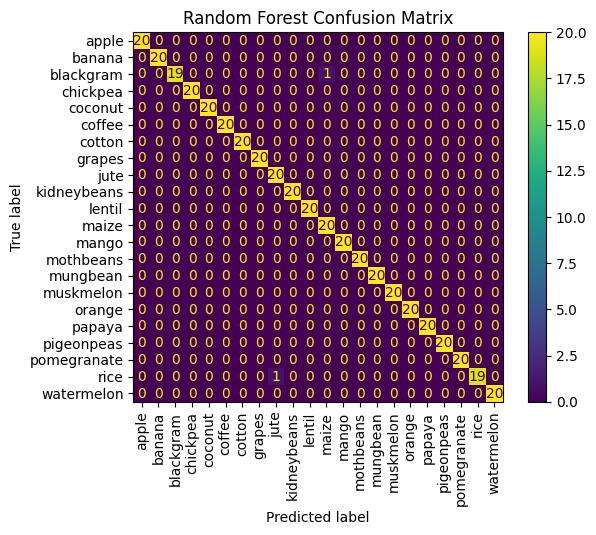

In [15]:
# Confusion Matrix
plt.figure(figsize=(12, 8))
ConfusionMatrixDisplay.from_predictions(y_test_ml, y_pred_ml, display_labels=le.classes_, xticks_rotation=90)
plt.title("Random Forest Confusion Matrix")
plt.show()

#### Deep Learning Model (Feed Forward MLP)

In [16]:
# Scaled + One-Hot
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

y_categorical = to_categorical(y_encoded)

X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_scaled, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

In [17]:
# Define model
model = Sequential([
    Dense(128, input_dim=7, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(len(le.classes_), activation='softmax')
])

model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-05-02 20:21:55.591028: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [18]:
# Train model
history = model.fit(X_train_dl, y_train_dl, validation_data=(X_test_dl, y_test_dl), epochs=50, batch_size=32, verbose=0)

In [19]:
# Evaluate model
loss, accuracy = model.evaluate(X_test_dl, y_test_dl, verbose=0)
print(f"\nDL Model Accuracy: {accuracy:.4f}")


DL Model Accuracy: 0.9818


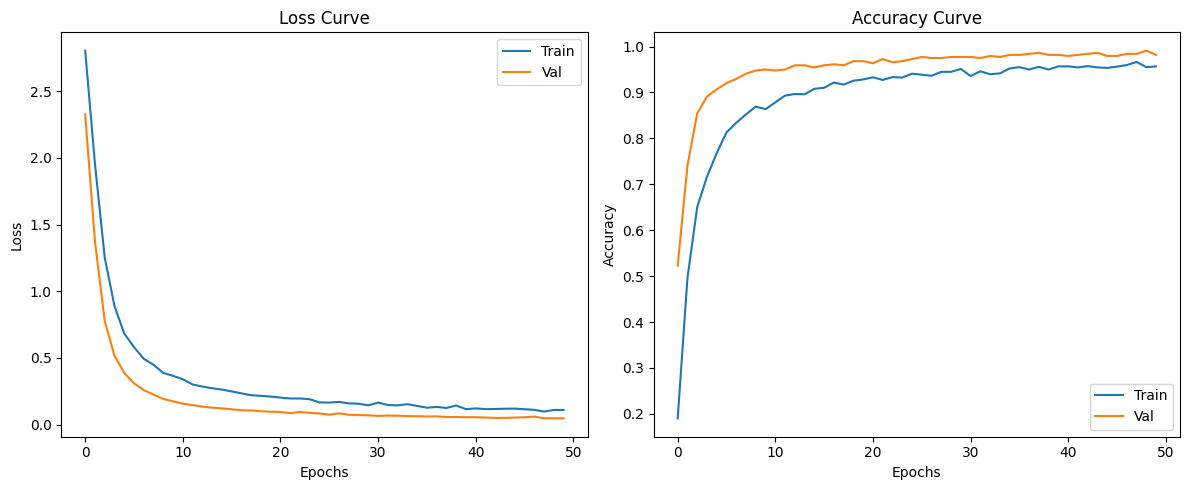

In [20]:
# Plot loss/accuracy curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

In [21]:
# Predictions and class labels
y_pred_dl = model.predict(X_test_dl)
y_pred_classes = np.argmax(y_pred_dl, axis=1)
y_true_classes = np.argmax(y_test_dl, axis=1)

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [22]:
# Classification Report
print("Deep Learning Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=le.classes_))

Deep Learning Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       0.87      1.00      0.93        20
      grapes       1.00      1.00      1.00        20
        jute       0.86      0.95      0.90        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       1.00      0.85      0.92        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00

<Figure size 1200x800 with 0 Axes>

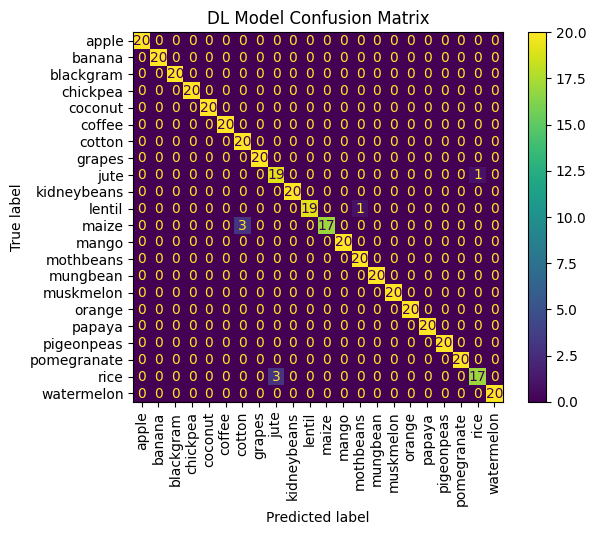

In [23]:
# Confusion Matrix
plt.figure(figsize=(12, 8))
ConfusionMatrixDisplay.from_predictions(y_true_classes, y_pred_classes, display_labels=le.classes_, xticks_rotation=90)
plt.title("DL Model Confusion Matrix")
plt.show()

### Saving our models

In [28]:
import joblib
joblib.dump(rf, "random_forest_model.pkl")

['random_forest_model.pkl']

In [29]:
model.save("crop_recommendation_model.h5")